# What is statistics?

Probability theory computes probabilities of complex events given the underlying base probabilities.

Statistics takes us in the opposite direction.

We are given **data** that was generated by a **Stochastic process**

We **infer** properties of the underlying base probabilities.

# Example:  deciding whether a coin is biased.

In a previous notebook we discussed the distribution of the number of heads when flipping a fair coin many times.

Let's turn the question around: we flip a coin 1000 times and get 570 heads.

Can we conclude that the coin is biased (not fair) ?

What can we conclude if we got 507 heads?

### The Logic of Statistical inference
The answer uses the following logic.

* Suppose that the coin is fair.

* Use **probability theory** to compute the probability of getting at least 570 (or 507) heads.

* If this probability is very small, then we can **reject** <font color='red'>with confidence</font> the hypothesis that the coin is fair.

## Calculating the answer
Recall the simulations we did in the video "What is probability".

We used $x_i=-1$ for tails and $x_i=+1$ for heads.

We looked at the sum $S_k=\sum_{i=1}^k x_i$, here $k=1000$.

If number of heads is $570$ then $S_{1000} = 570-430 = 140$  

It is very unlikely that $|S_{1000}| > 4\sqrt{k} \approx 126.5$

In [ ]:
from math import sqrt
4*sqrt(1000)

126.49110640673517

It is very unlikely that the coin is unbiased.

### What about 507 heads?

507 heads = 493 tails $ \Rightarrow S_n = 14$,       $\;\;\;14 \ll 126.5$

We cannot conclude that coin is biased.

## Conclusion
The probability that an unbiased coin would generate a sequence with 570 or more heads is extremely small. From which we can conclude, <font color='red'>with high confidence</font>, that the coin **is** biased.

On the other hand, $\big| S_{1000} \big | \geq 507$ is quite likely. So getting 507 heads does not provide evidence that the coin is biased.

# Real-World examples
You might ask "why should I care whether a coin is biased?"

* This is a valid critique.
* We will give a few real-world cases in which we want to know whether a "coin" is biased or not.

## Case I: Polls
* Suppose elections will take place in a few days and we want to know how people plan to vote.
* Suppose there are just two parties: **D** and **R**.

* We could try and ask **all** potential voters.

* That would be very expensive.

* Instead, we can use a poll: call up a small randomly selected set of people.

* Call $n$ people at random and count the number of **D** votes.

* Can you say <font color='red'>with confidence</font> that there are more **D** votes, or more **R** votes?

* Mathematically equivalent to flipping a biased coin and

* asking whether you can say <font color='red'>with confidence</font> that it is biased towards "Heads" or towards "Tails"

## Case 2: A/B testing
A common practice when optimizing a web page is to perform A/B tests.

* A/B refer to two alternative designs for the page.

![AB](images/AB.png)

* To see which design users prefer we randomly present design A or design B.

* We measure how long the user stayed on a page, or whether the user clicked on an advertisement.

* We want to decide, <font color='red'>with confidence</font>, which of the two designs is better.

* Again: similar to making a decision <font color='red'>with confidence</font> on whether "Heads" is more probably than "Tails" or vice versa.

In [1]:
import pandas as pd
# Import data from GitHub (or from your local computer)
df = pd.read_csv("https://raw.githubusercontent.com/kirenz/datasets/master/wage.csv")

In [2]:
df.head()

,Unnamed: 0,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,231655,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,86582,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,161300,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,155159,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,11443,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


<Axes: xlabel='wage'>

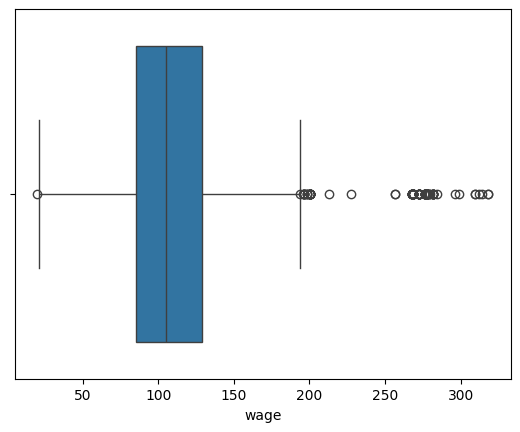

In [4]:
# prompt: boxplot

import seaborn as sns
sns.boxplot(x = "wage", data = df)


In [5]:
df.columns

Index(['Unnamed: 0', 'year', 'age', 'maritl', 'race', 'education', 'region',
       'jobclass', 'health', 'health_ins', 'logwage', 'wage'],
      dtype='object')

In [6]:
df.shape

(3000, 12)

In [7]:
# mode of age
df['age'].mode()

0    40
Name: age, dtype: int64

In [8]:
# mode of wage
df['wage'].mode()

0    118.884359
Name: wage, dtype: float64

In [9]:
# calculation of the mean (e.g. for age)
df["age"].mean()

42.41466666666667

In [10]:
# calculation of the mean (e.g. for wage)
df["wage"].mean()

111.70360820174345

In [11]:
# calculation of the mean (e.g. for age) and round the result
round(df["age"].mean(), 0)

42.0

In [12]:
# calculation of the mean (e.g. for wage) and round the result
round(df["wage"].mean(), 3)

111.704

In [13]:
# calculation of the median (e.g. for age)
df["age"].median()

42.0

In [14]:
# calculation of the median (e.g. for wage)
df["wage"].median()

104.921506533664

In [18]:
# prompt: statistical summary

df.describe()


,Unnamed: 0,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,218883.373000,2005.791000,42.414667,4.653905,111.703608
std,145654.072587,2.026167,11.542406,0.351753,41.728595
min,7373.000000,2003.000000,18.000000,3.000000,20.085537
25%,85622.250000,2004.000000,33.750000,4.447158,85.383940
50%,228799.500000,2006.000000,42.000000,4.653213,104.921507
75%,374759.500000,2008.000000,51.000000,4.857332,128.680488
max,453870.000000,2009.000000,80.000000,5.763128,318.342430


### Measures of dispersion

In [19]:
# quantiles
df['age'].quantile([.25, .5, .75])

0.25    33.75
0.50    42.00
0.75    51.00
Name: age, dtype: float64

In [20]:
# Range
df['age'].max() - df['age'].min()

62

In [21]:
# standard deviation
round(df['age'].std(),2)

11.54

### Summary statistics

In [22]:
# summary statistics for all numerical columns
round(df.describe(),2)

,Unnamed: 0,year,age,logwage,wage
count,3000.00,3000.00,3000.00,3000.00,3000.00
mean,218883.37,2005.79,42.41,4.65,111.70
std,145654.07,2.03,11.54,0.35,41.73
min,7373.00,2003.00,18.00,3.00,20.09
25%,85622.25,2004.00,33.75,4.45,85.38
50%,228799.50,2006.00,42.00,4.65,104.92
75%,374759.50,2008.00,51.00,4.86,128.68
max,453870.00,2009.00,80.00,5.76,318.34


#### Compare summary statistics for specific groups in the data

In [23]:
# summary statistics by groups
df['age'].groupby(df['education']).describe()

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
1. < HS Grad,268.0,41.794776,12.611111,18.0,33.0,41.5,50.25,75.0
2. HS Grad,971.0,42.217302,12.023480,18.0,33.0,42.0,50.00,80.0
3. Some College,650.0,40.887692,11.523327,18.0,32.0,40.0,49.00,80.0
4. College Grad,685.0,42.773723,10.902406,22.0,34.0,43.0,51.00,76.0
5. Advanced Degree,426.0,45.007042,10.263468,25.0,38.0,44.0,53.00,76.0


In [24]:
# summary statistics by groups
df['wage'].groupby(df['race']).describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
1. White,2480.0,112.563666,41.733830,20.085537,86.695155,106.348256,130.042934,314.329336
2. Black,293.0,101.601177,37.162486,23.274704,81.283253,94.072715,117.146817,318.342430
3. Asian,190.0,120.288288,46.422514,34.607418,87.981033,115.375039,144.828129,299.262977
4. Other,37.0,89.973326,29.153530,38.223583,71.319639,81.283253,104.921507,169.528538


In [25]:
# summary statistics by groups
df['age'].groupby(df['race']).describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
1. White,2480.0,42.394758,11.365655,18.0,34.00,42.0,51.0,80.0
2. Black,293.0,43.563140,13.012913,18.0,33.00,44.0,52.0,75.0
3. Asian,190.0,41.821053,11.218823,22.0,32.25,40.0,50.0,76.0
4. Other,37.0,37.702703,11.553895,21.0,28.00,39.0,47.0,65.0


# Summary
Statistics is about analyzing real-world data and drawing conclusions.

Examples include:

* Using polls to estimate public opinion.

* performing A/B tests to design web pages

* Estimating the rate of global warming.

* Deciding whether a medical procedure is effective